<a href="https://colab.research.google.com/github/tomferreiras-eng/PROYECTO-CLASIFICACION-CANCER-MAMA/blob/main/Segmentacion_Clientes_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación de Clientes de E-commerce (Clustering)
Este notebook contiene un flujo de trabajo para agrupar clientes mediante **Aprendizaje No Supervisado (K-Means)**, descubriendo patrones ocultos de compra y navegación.

## 1. Importar Librerías
Cargamos las dependencias necesarias para manipular datos, visualizar y entrenar el modelo de segmentación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')

## 2. Carga y Exploración del Dataset (EDA)
Importamos el archivo `dataset_clientes_ecommerce.csv` y analizamos distribuciones.

Dataset cargado exitosamente.

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   edad                            1000 non-null   int64  
 1   genero                          1000 non-null   object 
 2   frecuencia_compras_mensual      1000 non-null   int64  
 3   promedio_gasto_compra           1000 non-null   float64
 4   tiempo_navegacion_promedio_min  1000 non-null   int64  
 5   usa_dispositivo_movil           1000 non-null   object 
 6   categorias_preferidas           1000 non-null   object 
 7   calificacion_servicio           1000 non-null   float64
 8   responde_promociones            1000 non-null   object 
 9   pais                            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


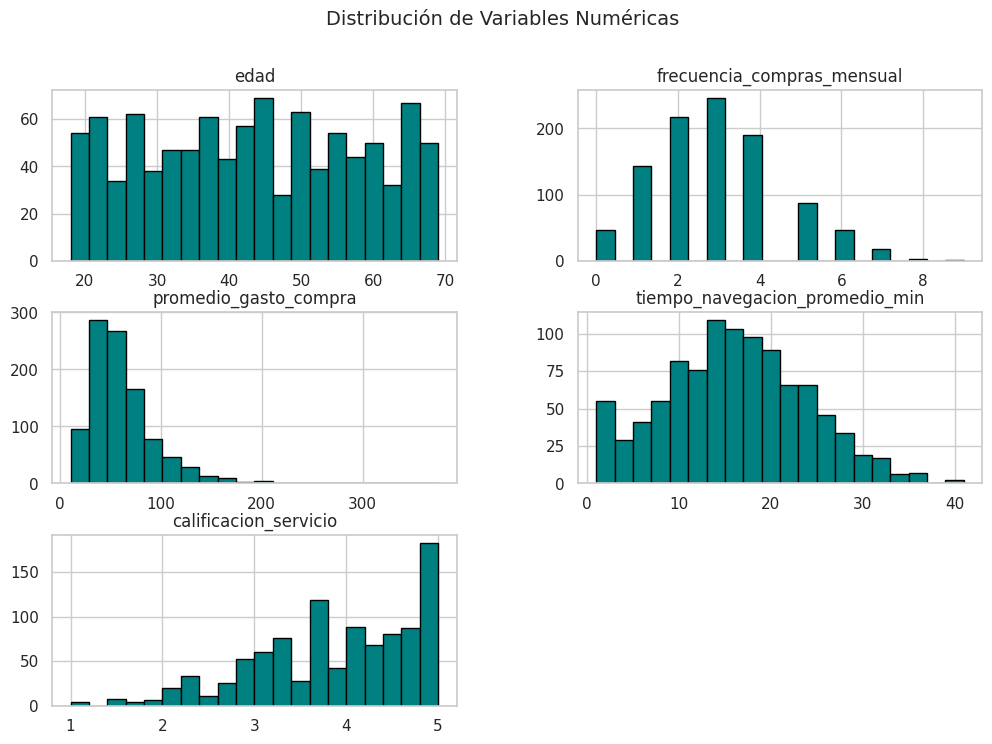

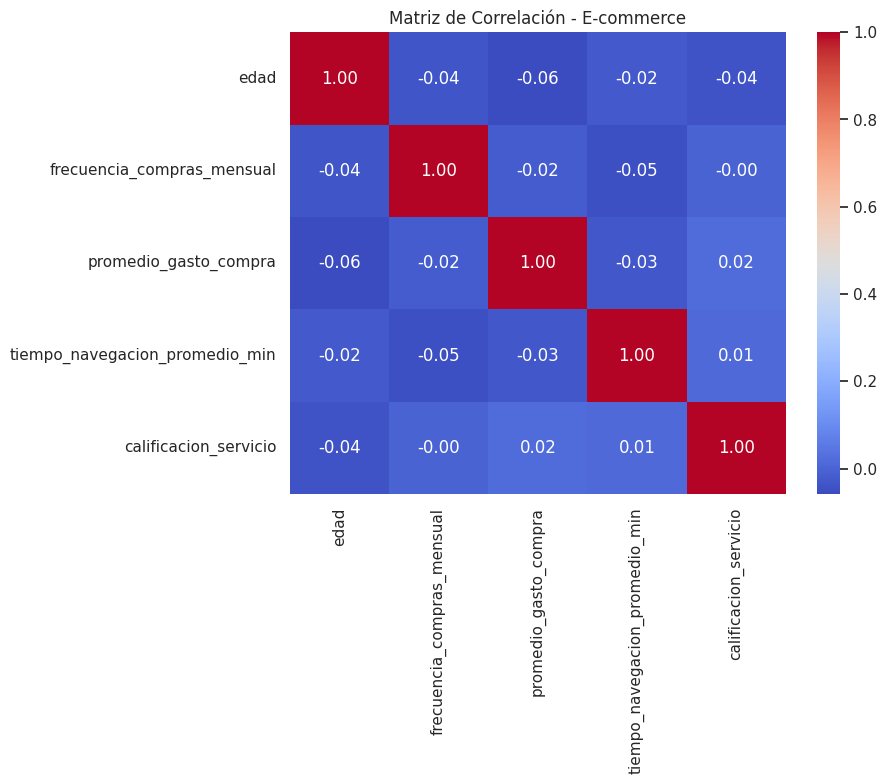

In [2]:
# Cargar datos
try:
    df = pd.read_csv('dataset_clientes_ecommerce.csv')
    print('Dataset cargado exitosamente.')
except FileNotFoundError:
    print('Error: El archivo no se encuentra en el directorio.')

# Inspección inicial
print('\n--- Información General ---')
df.info()

# Variables Numéricas y Categóricas
numeric_cols = ['edad', 'frecuencia_compras_mensual', 'promedio_gasto_compra', 'tiempo_navegacion_promedio_min', 'calificacion_servicio']
categorical_cols = ['genero', 'usa_dispositivo_movil', 'categorias_preferidas', 'responde_promociones', 'pais']

# Distribuciones Individuales
df[numeric_cols].hist(figsize=(12, 8), bins=20, color='teal', edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas', fontsize=14)
plt.show()

# Matriz de Correlación
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación - E-commerce')
plt.show()

## 3. Preparación para Clustering
Codificamos variables categóricas (OneHot) y estandarizamos las numéricas (StandardScaler) usando `ColumnTransformer`.

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

X_procesado = preprocessor.fit_transform(df)
print('Datos listos para el algoritmo.')

Datos listos para el algoritmo.


## 4. Aplicación de Clustering (K-Means)
Evaluamos la cantidad óptima de clusters usando el **Método del Codo** y **Silhouette Score**.

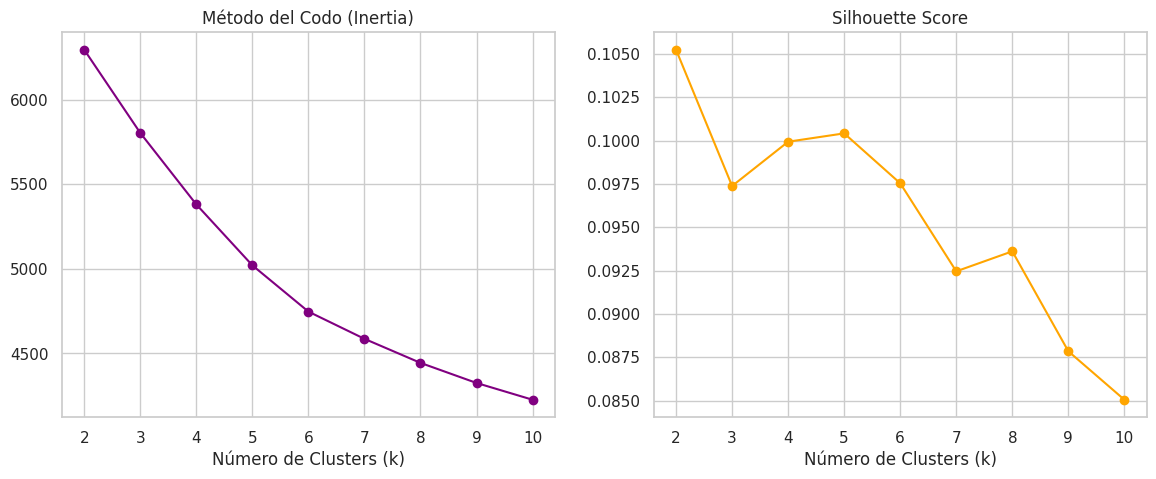

In [4]:
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_procesado)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_procesado, kmeans.labels_))

# Gráficos de Evaluación
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K_range, inertia, marker='o', color='purple')
ax[0].set_title('Método del Codo (Inertia)')
ax[0].set_xlabel('Número de Clusters (k)')

ax[1].plot(K_range, sil_scores, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Número de Clusters (k)')
plt.show()

### 4.1 Entrenar el Modelo Final (k=3)
En base a los criterios de negocio, agrupamos a los clientes en 3 perfiles distintos.

,edad,frecuencia_compras_mensual,promedio_gasto_compra,tiempo_navegacion_promedio_min,calificacion_servicio
Cluster,,,,,
0,30.422414,3.129310,74.659598,14.672414,4.348851
1,42.929293,2.996633,56.746431,16.892256,2.802357
2,56.400000,2.740845,54.814366,15.681690,4.297746


/tmp/ipykernel_3195/2616204141.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster', palette='viridis')


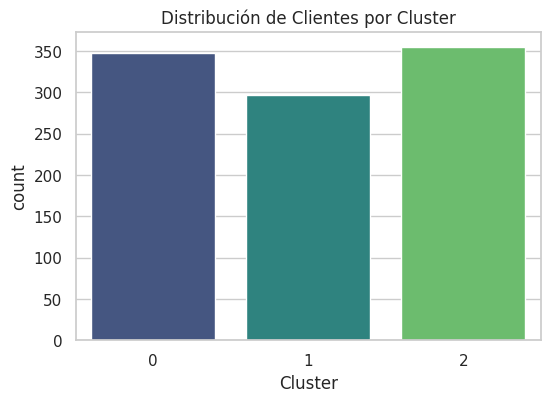

In [5]:
# Modelo Final
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_procesado)

# Características de los clusters
resumen_clusters = df.groupby('Cluster')[numeric_cols].mean()
display(resumen_clusters)

# Visualizar tamaños de los clusters
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Cluster', palette='viridis')
plt.title('Distribución de Clientes por Cluster')
plt.show()

## 5. Conclusiones Finales y Recomendaciones Estratégicas

Tras aplicar técnicas de aprendizaje no supervisado (K-Means) al conjunto de datos de clientes, hemos logrado ir más allá de los datos demográficos básicos para descubrir **tres perfiles de comportamiento** claramente diferenciados. Este análisis revela oportunidades críticas para la optimización de marketing y la experiencia del usuario (UX).

### Perfiles Descubiertos y Plan de Acción:

* 🥇 **Cluster 0: "Jóvenes Premium" (El segmento más rentable)**
    * **Perfil:** Clientes alrededor de los 30 años. Se caracterizan por tener la **mayor frecuencia de compra** y el **mayor ticket promedio** (~$74.65 USD). Su nivel de satisfacción es excelente (4.3/5).
    * **Acción Estratégica:** Implementar programas de lealtad VIP. Son el público ideal para campañas de *up-selling* (ventas de mayor valor), lanzamientos exclusivos de nuevos productos y estrategias de referidos.

* ⚠️ **Cluster 1: "Adultos Insatisfechos" (Alerta de fricción en UX)**
    * **Perfil:** Adultos de mediana edad (~43 años) con un gasto moderado. Pasan el **mayor tiempo navegando** en el sitio web (~17 minutos), pero tienen una **calificación de servicio críticamente baja** (2.8/5).
    * **Acción Estratégica:** Este es el hallazgo más urgente. El alto tiempo de navegación combinado con baja satisfacción sugiere problemas de usabilidad en la plataforma (difícil proceso de pago, buscador deficiente o falta de soporte). Se recomienda realizar pruebas de usabilidad (A/B testing) y enviar encuestas de retroalimentación dirigidas específicamente a este segmento para identificar y corregir los puntos de fricción.

* 🥉 **Cluster 2: "Seniors Esporádicos" (Clientes estables y pasivos)**
    * **Perfil:** Clientes mayores (~56 años). Presentan la menor frecuencia de compras y el gasto más conservador (~$54.81 USD), pero están altamente satisfechos con el servicio (4.2/5).
    * **Acción Estratégica:** Mantener el contacto sin saturarlos. Se benefician de campañas de *retargeting* estacionales (como Día de la Madre/Padre, Navidad) y correos electrónicos con recomendaciones de productos claras y directas, priorizando la facilidad de compra.

**Reflexión Final:**
El uso de algoritmos de clustering nos permitió identificar un problema oculto de insatisfacción en un sector clave de la audiencia (Cluster 1) que los promedios generales habrían enmascarado. Esto demuestra cómo el Machine Learning transforma datos crudos en decisiones de negocio rentables y dirigidas.